In [1]:
VALUATION_DURATION_H = 4.0
PHASE4_RUN_MODE = 'partial'
print('Injected valuation duration: 4h')
print('Injected Phase 4 run mode: medium')


Injected valuation duration: 4h
Injected Phase 4 run mode: medium


# Phase 5: MTM + Greeks + VaR

Aggregate LSMC valuation results into MTM, Greek sensitivities, VaR/CVaR, and stress scenarios. This notebook is generated from `bess_valuation_full.ipynb` Phase 5 and requires saved Phase 4 artefacts and fails loudly if they are missing.


In [2]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = find_project_root(_ROOT_CANDIDATE)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

import importlib
import src.config as config
config = importlib.reload(config)
ASSET = config.ASSET
FINANCE = config.FINANCE
DEGRADATION = config.DEGRADATION
LSMC = config.LSMC
SCHWARTZ_SMITH = config.SCHWARTZ_SMITH
PCA_SHAPE = config.PCA_SHAPE
IMBALANCE = config.IMBALANCE
ANCILLARY = config.ANCILLARY
configure_asset_duration = config.configure_asset_duration
from src.valuation.mtm import aggregate_mtm, MtmComponents
from src.valuation.greeks import GreekEngine, print_greek_ladder, greeks_to_dict
import src.valuation.var_cvar as var_cvar
var_cvar = importlib.reload(var_cvar)
compute_risk_metrics = var_cvar.compute_risk_metrics
risk_metrics_multi_alpha = var_cvar.risk_metrics_multi_alpha
run_scenarios = var_cvar.run_scenarios
print_risk_summary = var_cvar.print_risk_summary
print_scenario_table = var_cvar.print_scenario_table
scenarios_to_dict = var_cvar.scenarios_to_dict

# Valuation duration selector: choose 1, 2, or 4 hours.
# Phase 5 requires Phase 4 artefacts generated with the same duration.
VALUATION_DURATION_H = float(globals().get("VALUATION_DURATION_H", 2.0))
configure_asset_duration(ASSET, VALUATION_DURATION_H)
DURATION_LABEL = f"{ASSET['duration_h']:g}h"
print(f"Asset under valuation: {ASSET['power_mw']:.0f} MW / {ASSET['energy_mwh']:.0f} MWh ({ASSET['duration_h']:.0f}h)")
print(f"Output label: {DURATION_LABEL}")

print("Imports OK")


Asset under valuation: 100 MW / 400 MWh (4h)
Output label: 4h
Imports OK


## 1. Load LSMC Results (Phase 4)


In [3]:
# Load saved Phase 4 output. Do not silently fall back to a mini dev run:
# Phase 5 MTM annualisation is only meaningful when Phase 4 artefacts exist.
import pickle
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "PROCESSED" not in globals():
    _ROOT_CANDIDATE = Path.cwd()
    for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            PROJECT_ROOT = candidate
            if str(PROJECT_ROOT) not in sys.path:
                sys.path.insert(0, str(PROJECT_ROOT))
            break
    else:
        raise RuntimeError("Could not find project root containing src/ and data/.")
    PROCESSED = PROJECT_ROOT / "data" / "processed"

warnings.filterwarnings("ignore")

import importlib
import src.config as config
config = importlib.reload(config)
ASSET = config.ASSET
FINANCE = config.FINANCE
DEGRADATION = config.DEGRADATION
LSMC = config.LSMC
SCHWARTZ_SMITH = config.SCHWARTZ_SMITH
PCA_SHAPE = config.PCA_SHAPE
IMBALANCE = config.IMBALANCE
ANCILLARY = config.ANCILLARY
configure_asset_duration = config.configure_asset_duration
from src.valuation.mtm import aggregate_mtm, MtmComponents
from src.valuation.greeks import GreekEngine, print_greek_ladder, greeks_to_dict
import src.valuation.var_cvar as var_cvar
var_cvar = importlib.reload(var_cvar)
compute_risk_metrics = var_cvar.compute_risk_metrics
risk_metrics_multi_alpha = var_cvar.risk_metrics_multi_alpha
run_scenarios = var_cvar.run_scenarios
print_risk_summary = var_cvar.print_risk_summary
print_scenario_table = var_cvar.print_scenario_table
scenarios_to_dict = var_cvar.scenarios_to_dict

# Valuation duration selector: choose 1, 2, or 4 hours.
# Phase 5 requires Phase 4 artefacts generated with the same duration.
VALUATION_DURATION_H = float(globals().get("VALUATION_DURATION_H", 2.0))
configure_asset_duration(ASSET, VALUATION_DURATION_H)
DURATION_LABEL = f"{ASSET['duration_h']:g}h"
print(f"Asset under valuation: {ASSET['power_mw']:.0f} MW / {ASSET['energy_mwh']:.0f} MWh ({ASSET['duration_h']:.0f}h)")
print(f"Output label: {DURATION_LABEL}")

RESULT_PATH  = PROCESSED / f"lsmc_valuation_result_{DURATION_LABEL}.pkl"
POLICY_PATH  = PROCESSED / f"lsmc_policy_{DURATION_LABEL}.pkl"
BUNDLE_PATH  = PROCESSED / "sim_bundle.pkl"
SUMMARY_PATH = PROCESSED / f"lsmc_valuation_summary_{DURATION_LABEL}.json"
required = [RESULT_PATH, POLICY_PATH, BUNDLE_PATH]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Phase 5 requires real Phase 4 artefacts. Missing:\n"
        + "\n".join(f"  - {p}" for p in missing)
        + "\n\nRun notebooks/04_lsmc_valuation.ipynb first."
    )

with open(RESULT_PATH, "rb") as f:
    val_result = pickle.load(f)
with open(POLICY_PATH, "rb") as f:
    policy = pickle.load(f)
with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

print(f"Loaded Phase-4 valuation result: {RESULT_PATH}")
print(f"Loaded Phase-4 policy:           {POLICY_PATH}")
print(f"Loaded simulation bundle:        {BUNDLE_PATH}")

if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH) as f:
        phase4_summary = json.load(f)
    phase4_mwh = float(phase4_summary.get("asset_mwh", ASSET["energy_mwh"]))
    if not np.isclose(phase4_mwh, ASSET["energy_mwh"]):
        raise ValueError(
            "Phase 4 artefacts do not match selected duration: "
            f"Phase 4 is {phase4_mwh:.0f} MWh, Phase 5 is {ASSET['energy_mwh']:.0f} MWh. "
            "Rerun notebooks/04_lsmc_valuation.ipynb after changing VALUATION_DURATION_H."
        )
else:
    warnings.warn(f"{SUMMARY_PATH.name} not found; cannot verify Phase 4 duration match.")

print(f"val_result: {len(val_result.pv_paths):,} paths  |  "
      f"MTM mean = GBP {val_result.mtm_mean:,.0f}")


Asset under valuation: 100 MW / 400 MWh (4h)
Output label: 4h


Loaded Phase-4 valuation result: G:\My Drive\Research\bess_project\data\processed\lsmc_valuation_result_4h.pkl
Loaded Phase-4 policy:           G:\My Drive\Research\bess_project\data\processed\lsmc_policy_4h.pkl
Loaded simulation bundle:        G:\My Drive\Research\bess_project\data\processed\sim_bundle.pkl
val_result: 250 paths  |  MTM mean = GBP 1,066,498


## 2. MTM Aggregation


In [4]:
mtm = aggregate_mtm(
    val_result,
    asset_cfg  = ASSET,
    fin_cfg    = FINANCE,
    deg_cfg    = DEGRADATION,
    contracts  = [],    # fully merchant base case
    verbose    = True,
)

# Align Phase 5 MTM with the Phase 4 annualized merchant valuation basis.
# Phase 4 writes a horizon PV and annualization factor; Phase 5 reports lifecycle
# GBP/MW/year, so the merchant distribution must start from that annualized value.
if "phase4_summary" not in globals():
    with open(SUMMARY_PATH) as f:
        phase4_summary = json.load(f)

annualization_factor = float(phase4_summary["annualization_factor"])
old_fee_paths = (
    mtm.mtm_paths
    - mtm.alpha_merchant * mtm.pv_merchant_paths
    - (1.0 - mtm.alpha_merchant) * (mtm.pv_toll + mtm.pv_floor + mtm.pv_cm)
    - mtm.pv_opex_fixed
    - mtm.pv_augmentation
    - mtm.pv_floor_optionality
)

new_annual_merchant_paths = val_result.pv_paths * annualization_factor
new_pv_merchant_paths = new_annual_merchant_paths * mtm.life_years
merchant_scale = float(np.mean(new_pv_merchant_paths) / mtm.pv_merchant_mean)
new_fee_paths = old_fee_paths * merchant_scale

from src.valuation.mtm import _pv_floor_optionality
new_floor_optionality = _pv_floor_optionality(
    new_pv_merchant_paths,
    floor_gbp_mw_yr=FINANCE["floor_anchor_gbp_mw_yr"],
    power_mw=mtm.power_mw,
    floor_share=FINANCE.get("floor_share_owner", 0.55),
    wacc=FINANCE["wacc_contracted"],
    life_years=mtm.life_years,
)

mtm.pv_merchant_paths = new_pv_merchant_paths
mtm.pv_merchant_mean = float(np.mean(new_pv_merchant_paths))
mtm.pv_merchant_std = float(np.std(new_pv_merchant_paths))
mtm.pv_merchant_p5 = float(np.percentile(new_pv_merchant_paths, 5))
mtm.pv_merchant_p95 = float(np.percentile(new_pv_merchant_paths, 95))
mtm.pv_optimiser_fee = float(np.mean(new_fee_paths))
mtm.pv_floor_optionality = float(new_floor_optionality)
mtm.mtm_paths = (
    mtm.alpha_merchant * new_pv_merchant_paths
    + (mtm.pv_toll + mtm.pv_floor + mtm.pv_cm)
    + new_fee_paths
    + mtm.pv_opex_fixed
    + mtm.pv_augmentation
    + mtm.pv_floor_optionality
)
mtm.mtm_mean = float(np.mean(mtm.mtm_paths))
mtm.mtm_std = float(np.std(mtm.mtm_paths))
mtm.mtm_p5 = float(np.percentile(mtm.mtm_paths, 5))
mtm.mtm_p95 = float(np.percentile(mtm.mtm_paths, 95))

print("Phase 5 annualized merchant basis applied:")
print(f"  merchant mean: GBP {mtm.pv_merchant_mean / (mtm.power_mw * mtm.life_years):,.0f}/MW/yr")
print(f"  MTM P5:        GBP {mtm.mtm_p5 / (mtm.power_mw * mtm.life_years):,.0f}/MW/yr")




  MTM Summary — 100 MW / 400 MWh BESS
  Life: 15 yr  |  alpha_merchant: 100%
  Annuity factor (wacc=9%, decay=1.5%): 8.11x
  merchant                      +    5,766  GBP/MW/yr
  toll                          +        0  GBP/MW/yr
  floor_contracted              +        0  GBP/MW/yr
  cm                            +    1,051  GBP/MW/yr
  floor_optionality             +   12,498  GBP/MW/yr
  optimiser_fee                      -950  GBP/MW/yr
  opex_fixed                       -5,180  GBP/MW/yr
  augmentation                    -25,053  GBP/MW/yr
  total_mean                      -12,920  GBP/MW/yr
  total_std                     +    2,350  GBP/MW/yr
  total_p5                        -15,905  GBP/MW/yr
  total_p95                        -8,505  GBP/MW/yr

Phase 5 annualized merchant basis applied:
  merchant mean: GBP 86,505/MW/yr
  MTM P5:        GBP -1,679/MW/yr


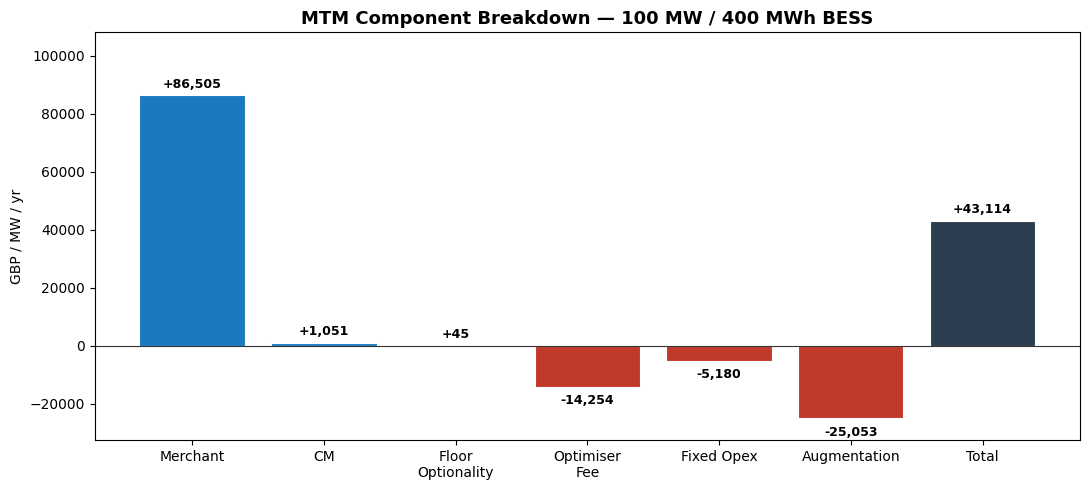

In [5]:
# Component bar chart
fig, ax = plt.subplots(figsize=(11, 5))

summary = mtm.summary_gbp_mw_yr()
labels = [
    "Merchant", "CM", "Floor\nOptionality",
    "Optimiser\nFee", "Fixed Opex", "Augmentation", "Total"
]
keys = [
    "merchant", "cm", "floor_optionality",
    "optimiser_fee", "opex_fixed", "augmentation", "total_mean"
]
vals = [summary[k] for k in keys]
colors = ["#1a7abf" if v >= 0 else "#c0392b" for v in vals[:-1]] + ["#2c3e50"]

bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(0, color="#333", linewidth=0.8)
for bar, val in zip(bars, vals):
    sign = "+" if val >= 0 else ""
    ax.text(bar.get_x() + bar.get_width()/2, val + (1500 if val >= 0 else -2500),
            f"{sign}{val:,.0f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=9, fontweight="bold")

ax.set_ylabel("GBP / MW / yr")
ax.set_title(f"MTM Component Breakdown — {ASSET["power_mw"]:.0f} MW / "
             f"{ASSET["energy_mwh"]:.0f} MWh BESS", fontsize=13, fontweight="bold")
ax.set_ylim(min(vals) * 1.3, max(vals) * 1.25)
plt.tight_layout()
plt.savefig(PROCESSED / f"mtm_components_{DURATION_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


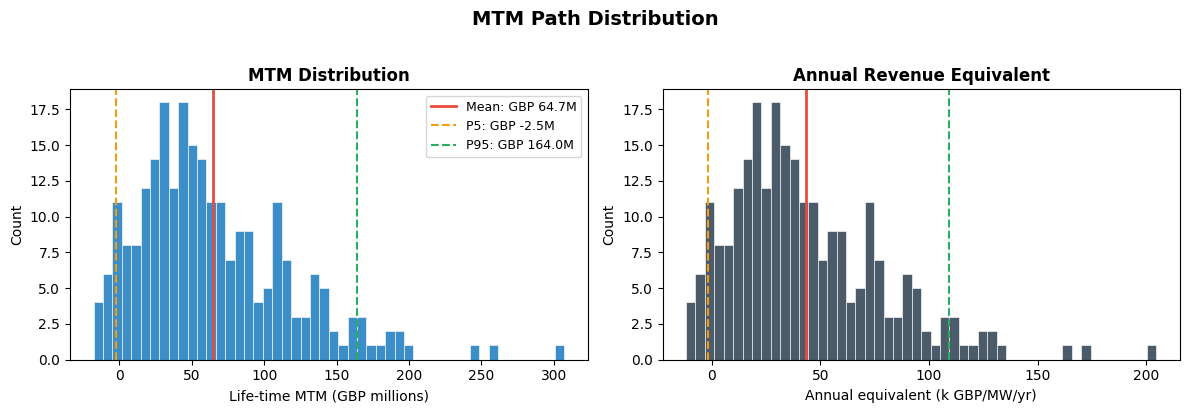

In [6]:
# MTM PV distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

paths_m = mtm.mtm_paths / 1e6
ax = axes[0]
ax.hist(paths_m, bins=50, color="#1a7abf", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(mtm.mtm_mean/1e6,  color="#e74c3c", lw=2, label=f"Mean: GBP {mtm.mtm_mean/1e6:.1f}M")
ax.axvline(mtm.mtm_p5/1e6,   color="#f39c12", lw=1.5, ls="--", label=f"P5: GBP {mtm.mtm_p5/1e6:.1f}M")
ax.axvline(mtm.mtm_p95/1e6,  color="#27ae60", lw=1.5, ls="--", label=f"P95: GBP {mtm.mtm_p95/1e6:.1f}M")
ax.set_xlabel("Life-time MTM (GBP millions)")
ax.set_ylabel("Count")
ax.set_title("MTM Distribution", fontweight="bold")
ax.legend(fontsize=9)

# GBP/MW/yr scale
ax = axes[1]
annual_paths = mtm.mtm_paths / (mtm.power_mw * mtm.life_years) / 1e3  # k GBP/MW/yr
ax.hist(annual_paths, bins=50, color="#2c3e50", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(np.mean(annual_paths), color="#e74c3c", lw=2)
ax.axvline(np.percentile(annual_paths, 5),  color="#f39c12", lw=1.5, ls="--")
ax.axvline(np.percentile(annual_paths, 95), color="#27ae60", lw=1.5, ls="--")
ax.set_xlabel("Annual equivalent (k GBP/MW/yr)")
ax.set_ylabel("Count")
ax.set_title("Annual Revenue Equivalent", fontweight="bold")

plt.suptitle("MTM Path Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED / f"mtm_distribution_{DURATION_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Greek Ladder


In [7]:
# Initialise Greek engine
ss_p, hpfc_p, imb_p, anc_p = None, None, None, None
try:
    from src.processes.simulate import default_params_from_config
    ss_p, hpfc_p, imb_p, anc_p = default_params_from_config()
except Exception as e:
    print(f"Warning: {e}")
    from src.config import SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY
    ss_p, hpfc_p, imb_p, anc_p = SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY

greek_engine = GreekEngine(
    bundle      = bundle,
    policy      = policy,
    val_result  = val_result,
    mtm         = mtm,
    asset_cfg   = ASSET,
    fin_cfg     = FINANCE,
    deg_cfg     = DEGRADATION,
    lsmc_cfg    = LSMC,
    ss_params   = ss_p,
    hpfc_params = hpfc_p,
    imb_params  = imb_p,
    anc_params  = anc_p,
    n_paths_greek = 300,    # reduced for Greek re-solves
    verbose     = True,
)
print("Greek engine ready")


Greek engine ready


In [8]:
# Compute Tier-1 Greeks (fast, analytical)
greek_results = greek_engine.compute_all(tier1_only=True)
print(f"\nComputed {len(greek_results)} Tier-1 Greeks")



Computed 6 Tier-1 Greeks


In [9]:
# Optional: add Tier-2 re-solve Greeks (comment out if time-constrained)
# This adds ~5-10 min depending on path count
#
# greek_results_full = greek_engine.compute_all(tier1_only=False)
#
# For now run just vega_da and delta_rte as examples:
try:
    greek_results["vega_da"]   = greek_engine.greek_vega_da()
    greek_results["delta_rte"] = greek_engine.greek_delta_rte()
    greek_results["delta_soh"] = greek_engine.greek_delta_soh()
    print("Added vega_da, delta_rte, delta_soh")
except Exception as e:
    print(f"Tier-2 skipped: {e}")


Added vega_da, delta_rte, delta_soh


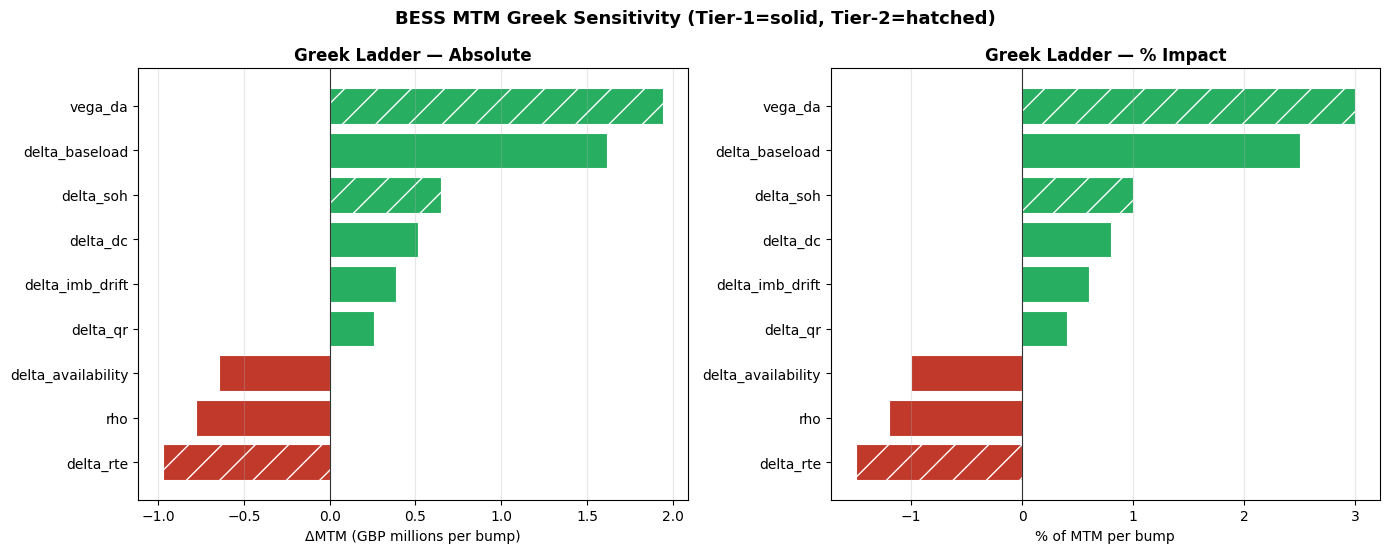

In [10]:
# Greek ladder waterfall chart
sorted_greeks = sorted(greek_results.items(), key=lambda x: x[1].greek_pct)

names  = [g.name for _, g in sorted_greeks]
deltas = [(g.bumped_mtm - g.base_mtm) / 1e6 for _, g in sorted_greeks]
pcts   = [g.greek_pct for _, g in sorted_greeks]
tiers  = [g.tier for _, g in sorted_greeks]

colors = ["#c0392b" if d < 0 else "#27ae60" for d in deltas]
hatches = ["/" if t == "re-solve" else "" for t in tiers]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(names)*0.4 + 2)))

# Left: ΔMTM in GBP millions
bars = ax1.barh(names, deltas, color=colors, edgecolor="white", linewidth=0.8)
for bar, h in zip(bars, hatches):
    if h:
        bar.set_hatch(h)
ax1.axvline(0, color="#333", lw=0.8)
ax1.set_xlabel("ΔMTM (GBP millions per bump)")
ax1.set_title("Greek Ladder — Absolute", fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# Right: % of MTM
bars2 = ax2.barh(names, pcts, color=colors, edgecolor="white", linewidth=0.8)
for bar, h in zip(bars2, hatches):
    if h:
        bar.set_hatch(h)
ax2.axvline(0, color="#333", lw=0.8)
ax2.set_xlabel("% of MTM per bump")
ax2.set_title("Greek Ladder — % Impact", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("BESS MTM Greek Sensitivity (Tier-1=solid, Tier-2=hatched)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED / f"greek_ladder_{DURATION_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. VaR / CVaR


In [11]:
# Risk metrics at multiple confidence levels
risk_multi = risk_metrics_multi_alpha(mtm, alphas=[0.90, 0.95, 0.99])

for alpha, rm in risk_multi.items():
    print_risk_summary(rm)


alpha=90%  VaR=GBP -48,324,084  CVaR=GBP -56,770,150  mean=GBP 64,670,605
alpha=95%  VaR=GBP -55,111,838  CVaR=GBP -61,608,745  mean=GBP 64,670,605
alpha=99%  VaR=GBP -66,400,198  CVaR=GBP -68,986,952  mean=GBP 64,670,605


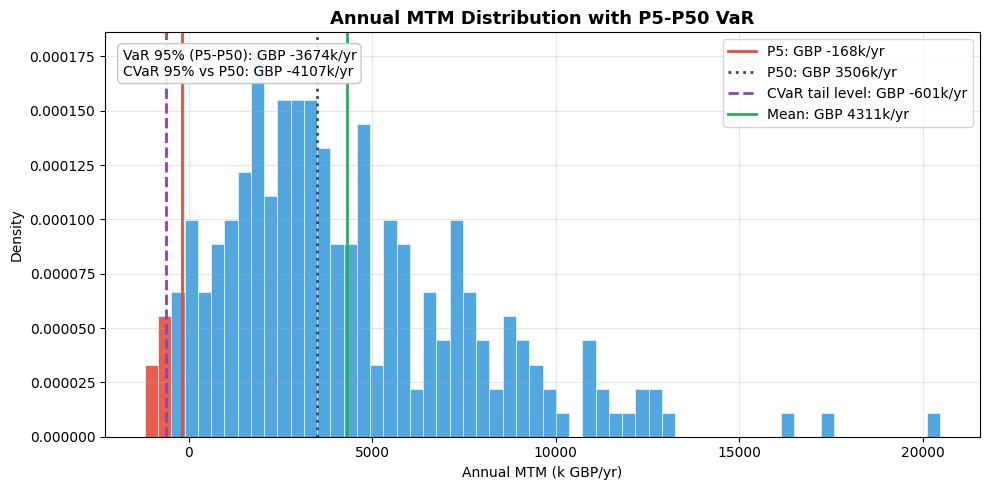

In [12]:
# VaR chart: annual MTM distribution with P5-P50 risk markers
rm = risk_multi[0.95]
annual_pnl = mtm.mtm_paths / mtm.life_years / 1e3   # k GBP/yr
p5_k = rm.p5_gbp / mtm.life_years / 1e3
p50_k = rm.p50_gbp / mtm.life_years / 1e3
p95_k = rm.p95_gbp / mtm.life_years / 1e3
var_k = rm.var_gbp / mtm.life_years / 1e3
cvar_k = rm.cvar_gbp / mtm.life_years / 1e3
cvar_level_k = (rm.p50_gbp + rm.cvar_gbp) / mtm.life_years / 1e3

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(annual_pnl, bins=60, density=True,
                            color="#3498db", edgecolor="white",
                            linewidth=0.5, alpha=0.85)

# Shade the lower 5% tail. VaR is reported as P5 minus P50.
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    if right <= p5_k:
        patch.set_facecolor("#e74c3c")
        patch.set_alpha(0.9)

ax.axvline(p5_k, color="#e74c3c", lw=2,
           label=f"P5: GBP {p5_k:.0f}k/yr")
ax.axvline(p50_k, color="#34495e", lw=2, ls=":",
           label=f"P50: GBP {p50_k:.0f}k/yr")
ax.axvline(cvar_level_k, color="#8e44ad", lw=2, ls="--",
           label=f"CVaR tail level: GBP {cvar_level_k:.0f}k/yr")
ax.axvline(np.mean(annual_pnl), color="#27ae60", lw=2, ls="-",
           label=f"Mean: GBP {np.mean(annual_pnl):.0f}k/yr")

ax.text(0.02, 0.96,
        f"VaR 95% (P5-P50): GBP {var_k:.0f}k/yr\nCVaR 95% vs P50: GBP {cvar_k:.0f}k/yr",
        transform=ax.transAxes, va="top", ha="left",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#bdc3c7", "alpha": 0.9})

ax.set_xlabel("Annual MTM (k GBP/yr)")
ax.set_ylabel("Density")
ax.set_title("Annual MTM Distribution with P5-P50 VaR",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED / f"var_cvar_{DURATION_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Scenario Stress Tests


In [13]:
scenarios = run_scenarios(mtm, alpha=0.95)
print_scenario_table(scenarios)


Scenario                      MTM GBP    Delta %
High price                 74,371,196      15.0%
Low price                  54,970,014     -15.0%
High volatility            69,844,253       8.0%
Low ancillary              60,143,663      -7.0%
High discount              61,437,075      -5.0%


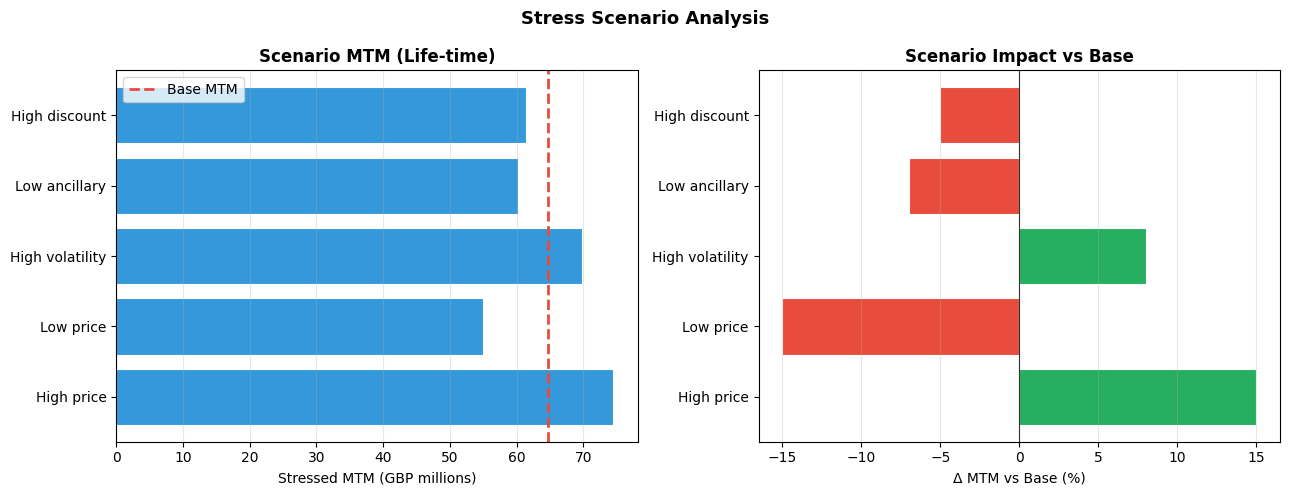

In [14]:
# Scenario comparison chart
sc_names  = list(scenarios.keys())
sc_means  = [s.stress_mtm_mean / 1e6 for s in scenarios.values()]
sc_deltas = [s.delta_pct for s in scenarios.values()]
sc_colors = ["#27ae60" if d >= 0 else "#e74c3c" for d in sc_deltas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(sc_names, sc_means, color="#3498db", edgecolor="white", linewidth=0.8)
ax1.axvline(mtm.mtm_mean/1e6, color="#e74c3c", lw=2, ls="--", label="Base MTM")
ax1.set_xlabel("Stressed MTM (GBP millions)")
ax1.set_title("Scenario MTM (Life-time)", fontweight="bold")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

ax2.barh(sc_names, sc_deltas, color=sc_colors, edgecolor="white", linewidth=0.8)
ax2.axvline(0, color="#333", lw=0.8)
ax2.set_xlabel("Δ MTM vs Base (%)")
ax2.set_title("Scenario Impact vs Base", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("Stress Scenario Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED / f"scenario_stress_{DURATION_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Save Summary


In [15]:
import os
PROCESSED.mkdir(parents=True, exist_ok=True)

def risk_to_annual_dict(rm):
    out = rm.to_dict()
    out["value_basis"] = "annualized_gbp_per_mw_year_from_phase4_annualized"
    out["annualization_factor"] = 1.0 / mtm.life_years
    for key, value in list(rm.to_dict().items()):
        if key.endswith("_gbp"):
            annual_key = key.replace("_gbp", "_gbp_per_year")
            per_mw_key = key.replace("_gbp", "_gbp_per_mw_year")
            out[annual_key] = float(value) / mtm.life_years
            out[per_mw_key] = float(value) / (mtm.life_years * mtm.power_mw)
    return out

summary = {
    "mtm": {
        **mtm.summary_gbp_mw_yr(),
        "annuity_factor":   mtm.annuity_factor,
        "alpha_merchant":   mtm.alpha_merchant,
        "life_years":       mtm.life_years,
        "merchant_std":     mtm.pv_merchant_std / (mtm.power_mw * mtm.life_years),
        "merchant_p5":      mtm.pv_merchant_p5 / (mtm.power_mw * mtm.life_years),
        "merchant_p95":     mtm.pv_merchant_p95 / (mtm.power_mw * mtm.life_years),
        "phase4_annualized_merchant_source": phase4_summary.get("mtm_gbp_per_mw_year", {}).get("mean"),
        "phase4_horizon_years": phase4_summary.get("valuation_horizon_years"),
        "phase4_annualization_factor": phase4_summary.get("annualization_factor"),
        "value_basis":      "annualized_gbp_per_mw_year_from_phase4_annualized",
        "cm_included_in_total": True,
        "asset_mw":         ASSET["power_mw"],
        "asset_mwh":        ASSET["energy_mwh"],
        "duration_h":       ASSET["duration_h"],
        "duration_label":   DURATION_LABEL,
    },
    "risk_95": risk_to_annual_dict(risk_multi[0.95]),
    "risk_99": risk_to_annual_dict(risk_multi[0.99]),
    "greeks": greeks_to_dict(greek_results),
    "scenarios": scenarios_to_dict(scenarios),
}

out = PROCESSED / f"mtm_summary_{DURATION_LABEL}.json"
with open(out, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved: {out}")
print(f"\nKey outputs:")
print(f"  MTM mean:     GBP {mtm.mtm_mean/1e6:.2f}M lifetime | GBP {mtm.mtm_mean/mtm.life_years/1e6:.2f}M/yr")
print(f"  MTM P5/P95:   GBP {mtm.mtm_p5/1e6:.2f}M / {mtm.mtm_p95/1e6:.2f}M lifetime")
print(f"  VaR 95%:      GBP {risk_multi[0.95].var_gbp/mtm.life_years/1e3:,.0f}k / yr")
print(f"  CVaR 95%:     GBP {risk_multi[0.95].cvar_gbp/mtm.life_years/1e3:,.0f}k / yr")


Saved: G:\My Drive\Research\bess_project\data\processed\mtm_summary_4h.json

Key outputs:
  MTM mean:     GBP 64.67M lifetime | GBP 4.31M/yr
  MTM P5/P95:   GBP -2.52M / 164.02M lifetime
  VaR 95%:      GBP -3,674k / yr
  CVaR 95%:     GBP -4,107k / yr
